# Griffiths Problem 1.11 -- expectation values, verified by SymPy (not by hand)
### the broken speedometer, its statistics, and the photonics payoff $\langle\cos^2\theta\rangle=\tfrac12$

A broken speedometer needle comes to rest at a **uniformly random angle** between $0$ and $\pi$.
That is the simplest continuous probability distribution, and Griffiths uses it to drill the
machinery every quantum problem needs: normalization, $\langle\theta\rangle$, $\langle\theta^2\rangle$,
the standard deviation $\sigma$, and averages of functions like $\sin\theta$, $\cos\theta$,
$\cos^2\theta$.

Instead of trusting the textbook's hand-algebra, we **derive every result symbolically with SymPy
and `assert` it against the book**, then **cross-check with a Torch Monte-Carlo**, and collect it in
a Pandas table. The last line is pure photonics: $\langle\cos^2\theta\rangle=\tfrac12$ is exactly
the **average Malus-law transmission** of light through a polarizer at a random angle.

Pipeline rung: this is the *statistics / polynomial-model* layer that later rides on pixel data ->
memory layout -> PDE solver -> CUDA. Executed on the Python 3.12 + Torch kernel.

In [1]:
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
sp.init_printing()
theta = sp.symbols('theta', real=True, nonnegative=True)
print("sympy", sp.__version__, "| torch", torch.__version__, "| pandas", pd.__version__)

sympy 1.14.0 | torch 2.11.0+cu128 | pandas 2.3.3


## (a) The probability density, and the wavefunction behind it

Uniform on $[0,\pi]$ and zero elsewhere, so by normalization the constant is $1/\pi$:
$$\rho(\theta)=\begin{cases}1/\pi & 0\le\theta\le\pi\\ 0 & \text{otherwise}.\end{cases}$$
In quantum language a probability density is $\rho=|\psi|^2$, so this corresponds to a **flat
wavefunction** $\psi(\theta)=1/\sqrt{\pi}$ on the interval. We verify normalization symbolically,
and recover $\rho$ by **differentiating the cumulative distribution** $F(\theta)=\int_0^\theta\rho$
-- the derivative check the hint is really about.

In [2]:
rho = 1/sp.pi                                   # density on [0, pi]
psi = 1/sp.sqrt(sp.pi)                          # wavefunction: rho = |psi|^2

norm = sp.integrate(rho, (theta, 0, sp.pi))
assert norm == 1, norm                          # total probability = 1
assert sp.simplify(psi**2 - rho) == 0           # |psi|^2 = rho

F = sp.integrate(rho, (theta, 0, theta))        # CDF = theta/pi
assert sp.simplify(sp.diff(F, theta) - rho) == 0    # differentiate CDF -> recover rho
print("normalization  int rho dtheta =", norm, " (=1)")
print("CDF F(theta) =", F, "  ->  dF/dtheta =", sp.diff(F, theta), "= rho  [verified]")

normalization  int rho dtheta = 1  (=1)
CDF F(theta) = theta/pi   ->  dF/dtheta = 1/pi = rho  [verified]


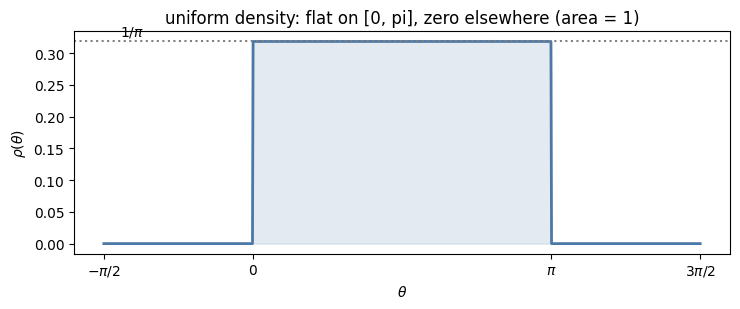

In [3]:
# Graph rho(theta) from -pi/2 to 3pi/2 (zero outside [0, pi]), as in the book
th = np.linspace(-np.pi/2, 3*np.pi/2, 1000)
rho_num = np.where((th >= 0) & (th <= np.pi), 1/np.pi, 0.0)
plt.figure(figsize=(7.5, 3.2))
plt.plot(th, rho_num, color="#4C78A8", lw=2)
plt.fill_between(th, rho_num, alpha=0.15, color="#4C78A8")
plt.axhline(1/np.pi, ls=":", color="gray"); plt.text(-1.4, 1/np.pi+0.01, r"$1/\pi$")
plt.xticks([-np.pi/2, 0, np.pi, 3*np.pi/2], [r"$-\pi/2$", "0", r"$\pi$", r"$3\pi/2$"])
plt.xlabel(r"$\theta$"); plt.ylabel(r"$\rho(\theta)$")
plt.title("uniform density: flat on [0, pi], zero elsewhere (area = 1)")
plt.tight_layout(); plt.show()

## (b) $\langle\theta\rangle$, $\langle\theta^2\rangle$, and $\sigma$ -- integrated exactly

$$\langle\theta\rangle=\int_0^\pi\theta\,\rho\,d\theta,\quad
\langle\theta^2\rangle=\int_0^\pi\theta^2\,\rho\,d\theta,\quad
\sigma=\sqrt{\langle\theta^2\rangle-\langle\theta\rangle^2}.$$
SymPy does the integrals; the `assert`s are the textbook answers $\pi/2$, $\pi^2/3$, $\pi/(2\sqrt3)$.

In [4]:
mean_theta  = sp.integrate(theta    * rho, (theta, 0, sp.pi))
mean_theta2 = sp.integrate(theta**2 * rho, (theta, 0, sp.pi))
var   = sp.simplify(mean_theta2 - mean_theta**2)
sigma = sp.simplify(sp.sqrt(var))

assert mean_theta  == sp.pi/2
assert mean_theta2 == sp.pi**2/3
assert sp.simplify(var - sp.pi**2/12) == 0
assert sp.simplify(sigma - sp.pi/(2*sp.sqrt(3))) == 0
for name, val in [("<theta>", mean_theta), ("<theta^2>", mean_theta2),
                  ("sigma^2", var), ("sigma", sigma)]:
    print(f"{name:9s} = {sp.nsimplify(val)} = {float(val):.6f}")

<theta>   = pi/2 = 1.570796
<theta^2> = pi**2/3 = 3.289868
sigma^2   = pi**2/12 = 0.822467
sigma     = sqrt(3)*pi/6 = 0.906900


## (c) $\langle\sin\theta\rangle$, $\langle\cos\theta\rangle$, $\langle\cos^2\theta\rangle$

Averages of functions of $\theta$: $\langle f\rangle=\int_0^\pi f(\theta)\,\rho\,d\theta$. The book
gives $2/\pi$, $0$, and $\tfrac12$ -- the last because $\sin^2+\cos^2=1$ and the two average
equally, so each is $\tfrac12$.

In [5]:
mean_sin  = sp.integrate(sp.sin(theta)    * rho, (theta, 0, sp.pi))
mean_cos  = sp.integrate(sp.cos(theta)    * rho, (theta, 0, sp.pi))
mean_cos2 = sp.integrate(sp.cos(theta)**2 * rho, (theta, 0, sp.pi))
mean_sin2 = sp.integrate(sp.sin(theta)**2 * rho, (theta, 0, sp.pi))

assert mean_sin  == 2/sp.pi
assert mean_cos  == 0
assert mean_cos2 == sp.Rational(1, 2)
assert sp.simplify(mean_sin2 + mean_cos2 - 1) == 0        # sin^2 + cos^2 -> averages sum to 1
print("<sin> =", mean_sin, "=", float(mean_sin))
print("<cos> =", mean_cos)
print("<cos^2> =", mean_cos2, "   <sin^2> =", mean_sin2, "  (sum = 1, and equal)")

<sin> = 2/pi = 0.6366197723675814
<cos> = 0
<cos^2> = 1/2    <sin^2> = 1/2   (sum = 1, and equal)


## Cross-check: Torch Monte-Carlo

The symbolic answers are exact; a numerical experiment should converge to them. Draw millions of
uniform angles $\theta\sim U(0,\pi)$ on the GPU/CPU with Torch and take sample means -- they track
the SymPy values, with error falling as $1/\sqrt{N}$ (the law of large numbers).

<theta>    torch +1.57100   exact +1.57080
<theta^2>  torch +3.29084   exact +3.28987
<sin>      torch +0.63649   exact +0.63662
<cos>      torch -0.00024   exact +0.00000
<cos^2>    torch +0.50013   exact +0.50000


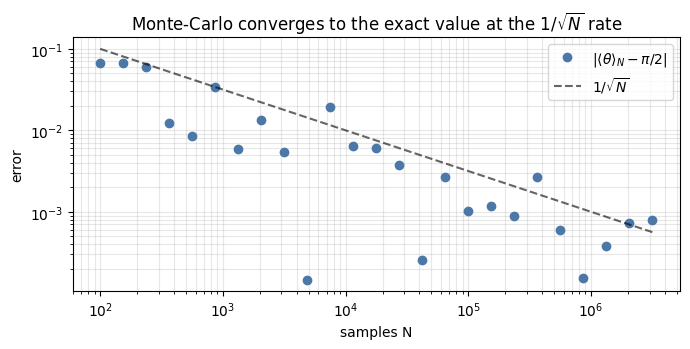

In [6]:
torch.manual_seed(0)
N = 4_000_000
th_s = torch.rand(N) * torch.pi                 # uniform on [0, pi)
est = {
    "<theta>":   th_s.mean(),
    "<theta^2>": (th_s**2).mean(),
    "<sin>":     th_s.sin().mean(),
    "<cos>":     th_s.cos().mean(),
    "<cos^2>":   (th_s.cos()**2).mean(),
}
exact = {"<theta>": mean_theta, "<theta^2>": mean_theta2, "<sin>": mean_sin,
         "<cos>": mean_cos, "<cos^2>": mean_cos2}
for k in est:
    print(f"{k:9s}  torch {float(est[k]):+.5f}   exact {float(exact[k]):+.5f}")

# convergence: |sample mean - exact| ~ 1/sqrt(N)
Ns = np.logspace(2, 6.5, 25).astype(int)
errs = [abs(float((torch.rand(int(n))*torch.pi).mean()) - float(mean_theta)) for n in Ns]
plt.figure(figsize=(7, 3.6))
plt.loglog(Ns, errs, "o", color="#4C78A8", label=r"$|\langle\theta\rangle_N-\pi/2|$")
plt.loglog(Ns, 1.0/np.sqrt(Ns), "k--", alpha=0.6, label=r"$1/\sqrt{N}$")
plt.xlabel("samples N"); plt.ylabel("error"); plt.legend()
plt.title("Monte-Carlo converges to the exact value at the $1/\\sqrt{N}$ rate")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## Summary table (Pandas): SymPy exact vs Torch numeric

In [7]:
rows = []
for k in exact:
    ex = float(exact[k]); nm = float(est[k])
    rows.append({"quantity": k, "sympy (exact)": sp.nsimplify(exact[k]),
                 "exact (float)": round(ex, 5), "torch MC": round(nm, 5),
                 "abs error": f"{abs(nm-ex):.2e}", "match": abs(nm-ex) < 2e-3})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
assert df["match"].all(), "a Monte-Carlo estimate drifted from the exact value"
print("\nall SymPy results confirmed by Torch Monte-Carlo.")

 quantity sympy (exact)  exact (float)  torch MC abs error  match
  <theta>          pi/2        1.57080   1.57100  2.06e-04   True
<theta^2>       pi**2/3        3.28987   3.29084  9.74e-04   True
    <sin>          2/pi        0.63662   0.63649  1.33e-04   True
    <cos>             0        0.00000  -0.00024  2.42e-04   True
  <cos^2>           1/2        0.50000   0.50013  1.30e-04   True

all SymPy results confirmed by Torch Monte-Carlo.


## Photonics payoff: $\langle\cos^2\theta\rangle=\tfrac12$ is average Malus transmission

**Malus's law**: light of intensity $I_0$ through a polarizer at angle $\theta$ to its polarization
transmits $I=I_0\cos^2\theta$. If the angle is uniformly random -- an unpolarized beam hitting a
polarizer, or randomly oriented optics -- the *average* transmission is exactly our
$\langle\cos^2\theta\rangle=\tfrac12$. That is why an ideal polarizer passes **half** of
unpolarized light. The same broken-speedometer integral that trains QM expectation values sets the
insertion loss of a polarizer.

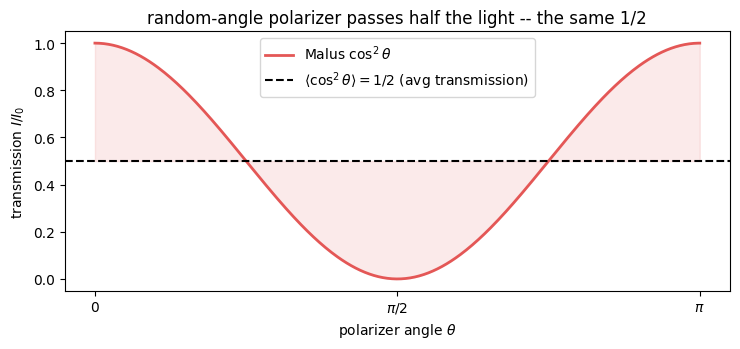

ideal polarizer on unpolarized light transmits <cos^2> = 0.5 = 1/2  (3.01 dB insertion loss)


In [8]:
ang = np.linspace(0, np.pi, 400)
plt.figure(figsize=(7.5, 3.6))
plt.plot(ang, np.cos(ang)**2, color="#E45756", lw=2, label=r"Malus $\cos^2\theta$")
plt.axhline(0.5, ls="--", color="k", label=r"$\langle\cos^2\theta\rangle=1/2$ (avg transmission)")
plt.fill_between(ang, np.cos(ang)**2, 0.5, alpha=0.12, color="#E45756")
plt.xticks([0, np.pi/2, np.pi], ["0", r"$\pi/2$", r"$\pi$"])
plt.xlabel(r"polarizer angle $\theta$"); plt.ylabel("transmission $I/I_0$")
plt.title("random-angle polarizer passes half the light -- the same 1/2")
plt.legend(); plt.tight_layout(); plt.show()
print("ideal polarizer on unpolarized light transmits <cos^2> =",
      float(mean_cos2), "= 1/2  (3.01 dB insertion loss)")

## What we did

* Built $\rho(\theta)=1/\pi$ (and its wavefunction $\psi=1/\sqrt\pi$, $\rho=|\psi|^2$), verified
  normalization and recovered $\rho$ by **differentiating the CDF** -- all in SymPy.
* Integrated **exactly** for $\langle\theta\rangle=\pi/2$, $\langle\theta^2\rangle=\pi^2/3$,
  $\sigma=\pi/(2\sqrt3)$, $\langle\sin\theta\rangle=2/\pi$, $\langle\cos\theta\rangle=0$,
  $\langle\cos^2\theta\rangle=\tfrac12$, each pinned with an `assert` against Griffiths.
* Cross-checked every value with a **Torch** Monte-Carlo ($1/\sqrt N$ convergence) and tabled it in
  **Pandas**.
* Cashed out the last integral as **Malus's law**: a polarizer at a random angle passes half the
  light.

Verification lives in code (SymPy + `assert`), not in prose -- the notebook *proves* the textbook.